<a href="https://colab.research.google.com/github/hoangson281205/ueh-ktlt-eco/blob/Gi%E1%BB%AFa-k%E1%BB%B3/Lab2(2_2_3)final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 2.2.3. Bài tập thực hành 1 :
Xây dựng mô hình từ giải thuật SVM trên dữ liệu bệnh tiểu đường.
Dữ liệu lấy từ https://www.kaggle.com/code/tumpanjawat/diabetes-eda-random-forest-hp


### Bước 1: Import thư viện và thiết lập hiển thị

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Hiển thị đồ họa trong notebook
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set(style='whitegrid')

print("oke ")


oke 


#### Bước 2: Tự nhận diện tên file đã upload

In [ ]:

import os, pandas as pd
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f" File bạn vừa upload: {filename}")
# Đọc dữ liệu
df = pd.read_csv(filename)
print("Dữ liệu đã nạp thành công.")
print("Shape (số hàng, số cột):", df.shape)
print("\nCác cột trong dữ liệu:")
print(df.columns.tolist())
# Xem 5 dòng đầu
display(df.head())
# Thông tin chi tiết kiểu dữ liệu
display(df.info())

Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset.csv
 File bạn vừa upload: diabetes_prediction_dataset.csv
Dữ liệu đã nạp thành công.
Shape (số hàng, số cột): (100000, 9)

Các cột trong dữ liệu:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


None

Bảng dữ liệu minh họa một số dòng đầu tiên, thể hiện rõ các đặc trưng nhân khẩu học và sức khỏe của người tham gia như tuổi, giới tính, tiền sử hút thuốc, bệnh tim và huyết áp.
Từ đó có thể thấy dữ liệu khá đa dạng, phản ánh nhiều khía cạnh khác nhau ảnh hưởng đến khả năng mắc tiểu đường.

Kết quả hiển thị thông tin chi tiết về kiểu dữ liệu và số lượng giá trị không rỗng của từng cột.
Hai cột gender và smoking_history thuộc loại object, cần được mã hóa trước khi đưa vào mô hình; các biến còn lại ở dạng số và có thể trực tiếp sử dụng cho quá trình chuẩn hóa và huấn luyện.


#### Bước 3: EDA cơ bản

Số dòng và cột: (100000, 9)

Tên các cột: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



Giá trị thiếu (missing values):
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Mô tả thống kê các biến số:


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00



Các cột dạng phân loại: ['gender', 'smoking_history']

Phân phối giá trị trong cột 'gender':
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Phân phối giá trị trong cột 'smoking_history':
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

Biến mục tiêu được chọn: diabetes
diabetes
0    91500
1     8500
Name: count, dtype: int64


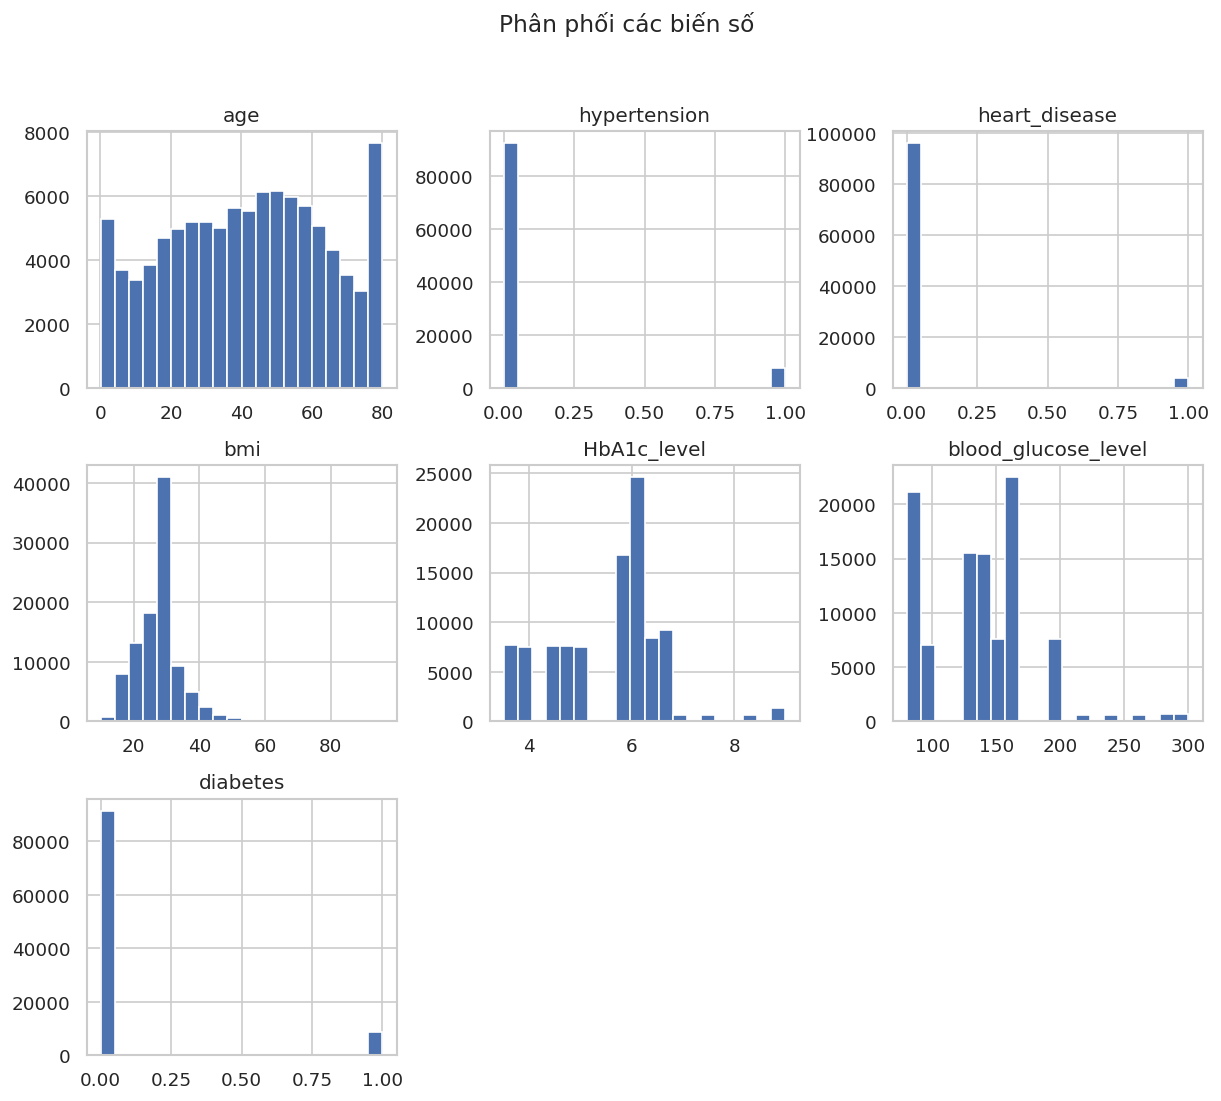

In [ ]:

# 1️ Tổng quan dữ liệu
print("Số dòng và cột:", df.shape)
print("\nTên các cột:", df.columns.tolist())
display(df.head())

# 2️ Kiểm tra giá trị bị thiếu
print("\nGiá trị thiếu (missing values):")
print(df.isnull().sum())

# 3️ Thống kê mô tả
print("\nMô tả thống kê các biến số:")
display(df.describe().T)

# 4️ Kiểm tra các biến phân loại (nếu có)
cat_cols = df.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    print("\nCác cột dạng phân loại:", list(cat_cols))
    for col in cat_cols:
        print(f"\nPhân phối giá trị trong cột '{col}':")
        print(df[col].value_counts())
else:
    print("\n Không có cột phân loại dạng object.")

# 5️ Kiểm tra phân phối của biến mục tiêu
target_candidates = [c for c in df.columns if c.lower() in ['outcome','diabetes','class','target']]
target = target_candidates[0] if target_candidates else df.columns[-1]
print(f"\nBiến mục tiêu được chọn: {target}")
print(df[target].value_counts())

# 6️ Biểu đồ phân phối (histogram) cho các biến số
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].hist(figsize=(12,10), bins=20)
plt.suptitle('Phân phối các biến số', fontsize=14)
plt.show()


**Nhận xét**

Dữ liệu gồm 100.000 dòng và 9 cột, bao gồm các biến: gender, age, hypertension, heart_disease, smoking_history, bmi, HbA1c_level, blood_glucose_level và diabetes

Kiểm tra cho thấy không có giá trị bị thiếu trong các biến, đảm bảo tính đầy đủ của dữ liệu. Thống kê mô tả cho thấy độ tuổi và mức đường huyết có độ dao động lớn, trong khi chỉ số BMI tập trung quanh mức trung bình khoảng 27. Các biến định lượng như age, HbA1c_level và blood_glucose_level có phân phối lệch phải, phản ánh sự xuất hiện của một nhóm nhỏ cá thể có giá trị cao hơn bình thường

Các biến phân loại gồm gender, hypertension và smoking_history. Kết quả cho thấy phần lớn người tham gia không hút thuốc và không mắc bệnh tim hay tăng huyết áp, tỷ lệ giới tính tương đối cân bằng

Biến mục tiêu diabetes có sự chênh lệch giữa hai nhóm, trong đó nhóm không mắc bệnh chiếm đa số. Biểu đồ phân phối dưới đây minh họa đặc điểm của các biến định lượng trong tập dữ liệu
Bảng thống kê mô tả cho thấy:

Độ tuổi trung bình của người tham gia là khoảng 41,9 tuổi, độ lệch chuẩn khá lớn (≈ 22,5), cho thấy dữ liệu bao phủ nhiều nhóm tuổi khác nhau.
BMI trung bình khoảng 27,3, nằm trong vùng thừa cân nhẹ, phản ánh một yếu tố nguy cơ tiềm ẩn với tiểu đường.
Mức HbA1c trung bình là 5,52, phần lớn vẫn trong ngưỡng bình thường (< 5,7), tuy nhiên có những cá nhân đạt mức cao tới 9,0.
Mức đường huyết (blood_glucose_level) dao động mạnh (trung bình 138, độ lệch chuẩn 40,7), cho thấy sự khác biệt đáng kể giữa các cá nhân.
Hai biến bệnh lý hypertension và heart_disease có trung bình lần lượt 0,074 và 0,039, tức chỉ khoảng 7,4% và 3,9% người tham gia mắc các bệnh này.

Về biến phân loại:
Giới tính có sự phân bố tương đối cân bằng: 58.552 nữ và 41.430 nam, cùng với một nhóm nhỏ “Other” (18 người).
Lịch sử hút thuốc (smoking_history) khá đa dạng, trong đó nhóm “No Info” và “never” chiếm tỷ lệ cao nhất, cho thấy phần lớn mẫu không có thói quen hút thuốc hoặc thiếu thông tin về yếu tố này.
Biến mục tiêu diabetes cho thấy dữ liệu mất cân bằng, với chỉ 8.500 ca mắc bệnh (≈ 8,5%) trên tổng số 100.000 quan sát. Điều này gợi ý rằng mô hình học máy sau này cần được hiệu chỉnh để tránh thiên lệch về nhóm không mắc bệnh.

Biểu đồ histogram thể hiện rõ đặc điểm phân phối của từng biến trong bộ dữ liệu:
Age: Phân phối khá đều từ 0 đến 80 tuổi, trong đó nhóm từ 40–70 tuổi chiếm tỷ trọng lớn, cho thấy dữ liệu tập trung chủ yếu ở nhóm trung niên và cao tuổi – nhóm có nguy cơ mắc tiểu đường cao hơn.
Hypertension và heart_disease: Cả hai biến đều có xu hướng lệch mạnh về 0, phản ánh rằng phần lớn người tham gia không mắc bệnh huyết áp cao hoặc tim mạch.
BMI: Phân phối lệch phải, tập trung chủ yếu quanh mức 20–35, tương ứng với nhóm bình thường đến thừa cân nhẹ.
HbA1c_level: Tập trung mạnh trong khoảng 4,5–6,5, tương ứng với mức đường huyết ổn định, chỉ một số ít người có giá trị cao bất thường (>8).
Blood_glucose_level: Có sự dao động lớn, phân phối lệch phải, xuất hiện một số điểm cực trị ở mức cao >200, thể hiện nhóm có nguy cơ hoặc đang mắc bệnh tiểu đường.
Diabetes: Biến mục tiêu thể hiện rõ sự mất cân bằng lớp, với phần lớn dữ liệu là nhóm không mắc bệnh (0) và một tỷ lệ nhỏ mắc bệnh (1).


#### Bước 4: Tiền xử lý dữ liệu cho SVM

In [ ]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1️ Xác định cột mục tiêu (label)
target_candidates = [c for c in df.columns if c.lower() in ['outcome', 'diabetes', 'class', 'target']]
label_col = target_candidates[0] if target_candidates else df.columns[-1]
print(" Cột mục tiêu được chọn:", label_col)

# 2️ Encode các biến phân loại (nếu có)
cat_cols = df.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    print("Các cột phân loại cần mã hóa:", list(cat_cols))
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col])
else:
    print(" Không có cột phân loại cần mã hóa.")

# 3️ Tách X, y
X = df.drop(columns=[label_col])
y = df[label_col]

# 4️ Scale dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5️ Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=101, stratify=y
)

print(f" Dữ liệu đã chia xong:")
print(f" - X_train: {X_train.shape}")
print(f" - X_test : {X_test.shape}")
print(f" - Tỉ lệ nhãn trong train:\n{y_train.value_counts(normalize=True).round(3)}")


 Cột mục tiêu được chọn: diabetes
Các cột phân loại cần mã hóa: ['gender', 'smoking_history']
 Dữ liệu đã chia xong:
 - X_train: (80000, 8)
 - X_test : (20000, 8)
 - Tỉ lệ nhãn trong train:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


**Giải thích**

LabelEncoder() giúp biến đổi dữ liệu kiểu chữ (Male/Female, Yes/No,...) thành số để mô hình hiểu được.

StandardScaler() giúp đưa các biến về cùng thang đo (trung bình 0, độ lệch chuẩn 1).

train_test_split(..., stratify=y) đảm bảo tỉ lệ nhãn 0/1 trong train và test tương tự như ban đầu.

#### Bước 5: Huấn luyện mô hình SVM cơ bản (kernel RBF mặc định)

 Kết quả mô hình SVM (kernel = 'rbf'):
 - Train Accuracy : 0.9642
 - Test Accuracy  : 0.9639
 - Test ROC AUC   : 0.9319

 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18300
           1       0.98      0.59      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.97      0.79      0.86     20000
weighted avg       0.96      0.96      0.96     20000



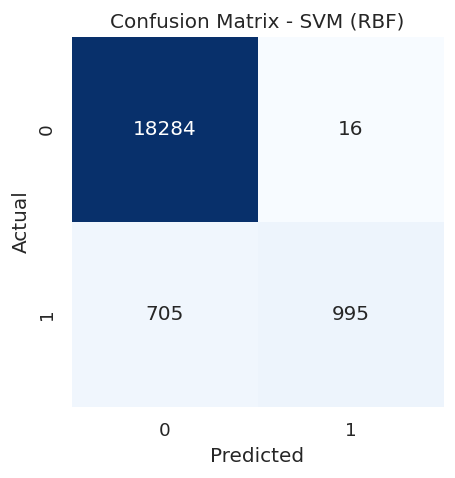

In [ ]:

from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# 1️ Khởi tạo mô hình SVM cơ bản
svm_model = svm.SVC(kernel='rbf', probability=True, random_state=42)

# 2️ Huấn luyện mô hình trên tập train
svm_model.fit(X_train, y_train)

# 3️ Dự đoán trên train và test
y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)

# 4️ Tính độ chính xác và ROC-AUC
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
y_test_proba = svm_model.predict_proba(X_test)[:, 1]
test_roc = roc_auc_score(y_test, y_test_proba)

# 5️ In kết quả
print(" Kết quả mô hình SVM (kernel = 'rbf'):")
print(f" - Train Accuracy : {train_acc:.4f}")
print(f" - Test Accuracy  : {test_acc:.4f}")
print(f" - Test ROC AUC   : {test_roc:.4f}")

# 6️ Báo cáo chi tiết
print("\n Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

# 7️ Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - SVM (RBF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Nhận xét**

Kết quả mô hình cho thấy hiệu suất dự đoán khá cao:
Train Accuracy: 0.9642
Test Accuracy: 0.9639
Test ROC-AUC: 0.9319
Điều này chứng tỏ mô hình học tốt trên tập huấn luyện và tổng quát hóa khá tốt trên tập kiểm định, không xuất hiện dấu hiệu overfitting rõ rệt.
Bảng Classification Report thể hiện chi tiết hiệu suất của mô hình trên từng lớp:
Với lớp 0 (không mắc bệnh), các chỉ số precision = 0.96, recall = 1.00 và f1-score = 0.98 cho thấy mô hình nhận diện chính xác hầu hết các cá nhân không mắc bệnh.
Tuy nhiên, với lớp 1 (mắc bệnh), recall chỉ đạt 0.59, trong khi precision khá cao (0.98). Điều này có nghĩa là mô hình dự đoán rất chính xác các trường hợp được nhận diện là mắc bệnh, nhưng lại bỏ sót nhiều ca mắc thật sự (hiện tượng false negative).
Ma trận nhầm lẫn (Confusion Matrix) củng cố nhận định này:
18,284 mẫu không mắc bệnh được dự đoán đúng, chỉ 16 mẫu bị nhầm.
Trong khi đó, 995 mẫu mắc bệnh được dự đoán đúng, còn 705 mẫu mắc bệnh bị dự đoán nhầm là không mắc.


#### Bước 6: So sánh các kernel của SVM và tìm tham số tối ưu

 Dữ liệu giảm còn: 3200 train | 800 test

 Đang huấn luyện và đánh giá từng kernel...

Kernel: linear   | Test Accuracy: 0.9613
Kernel: rbf      | Test Accuracy: 0.9537
Kernel: sigmoid  | Test Accuracy: 0.9025

 Kết quả so sánh các kernel:


,Kernel,Accuracy
0,linear,0.96125
1,rbf,0.95375
2,sigmoid,0.90250


/tmp/ipython-input-130860050.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Kernel', y='Accuracy', palette='crest')


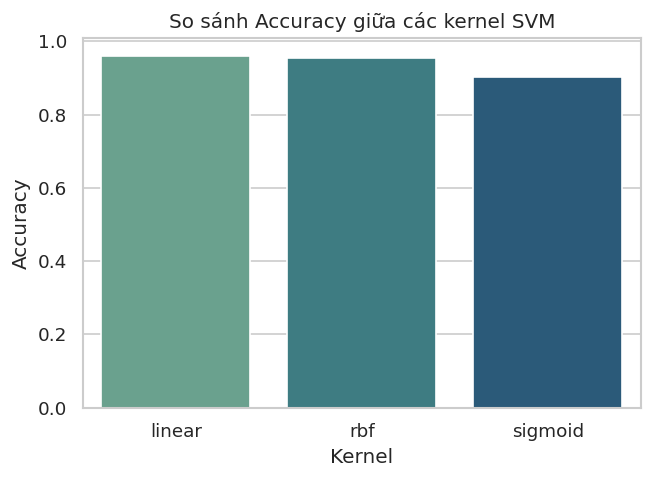

In [ ]:

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1️ Giảm dữ liệu cho nhẹ (khoảng 4000 mẫu)
X_small, _, y_small, _ = train_test_split(
    X_scaled, y, train_size=4000, random_state=42, stratify=y
)
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42, stratify=y_small
)
print(f" Dữ liệu giảm còn: {X_train.shape[0]} train | {X_test.shape[0]} test")

# 2️ Thử các kernel khác nhau
kernels = ['linear', 'rbf', 'sigmoid']
results = []

print("\n Đang huấn luyện và đánh giá từng kernel...\n")
for k in kernels:
    clf = svm.SVC(kernel=k, random_state=42)   # không dùng probability để tăng tốc
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Kernel': k, 'Accuracy': acc})
    print(f"Kernel: {k:<8} | Test Accuracy: {acc:.4f}")

# 3️ Tổng hợp kết quả
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("\n Kết quả so sánh các kernel:")
display(results_df)

# 4️ Biểu đồ trực quan
plt.figure(figsize=(6,4))
sns.barplot(data=results_df, x='Kernel', y='Accuracy', palette='crest')
plt.title('So sánh Accuracy giữa các kernel SVM')
plt.show()


**Nhận xét**

Sau khi giảm dữ liệu xuống còn 3200 mẫu huấn luyện và 800 mẫu kiểm tra, mô hình SVM được huấn luyện và đánh giá với ba loại kernel: linear, rbf, và sigmoid. Kết quả độ chính xác (Accuracy) của từng kernel như sau:
Linear kernel: đạt độ chính xác cao nhất với 96.13%
RBF kernel: đứng thứ hai với 95.38%
Sigmoid kernel: có độ chính xác thấp nhất, chỉ đạt 90.25%
Bảng và biểu đồ minh họa phía dưới đã thể hiện rõ sự chênh lệch này. Trong biểu đồ cột, ta thấy độ chính xác của linear và rbf khá sát nhau, trong khi sigmoid thấp hơn rõ rệt.
Kết luận
Linear kernel là lựa chọn tối ưu trong trường hợp này, vừa cho kết quả tốt nhất, vừa có thể tiết kiệm thời gian tính toán hơn so với RBF (vốn tính toán phức tạp hơn).
RBF kernel vẫn là một lựa chọn tốt nếu dữ liệu có phân bố phức tạp, tuy nhiên trong bài toán hiện tại, nó không vượt trội hơn linear.
